# MLOps Assignment: Predictive Maintenance Classification
### Starter Notebook

**Domain:** Industrial IoT / Manufacturing
**Task:** Multi-class failure type prediction
**Tools:** Pandera, MLflow, Optuna, Evidently, SHAP

---

## Business Context

A heavy-equipment manufacturer runs 10,000+ machines on the shop floor.
Each machine continuously streams six sensor readings. When a machine fails,
production halts - at a cost of ₹8-15 lakh per hour of downtime.

Your job is to build a full MLOps pipeline that:
1. Validates incoming sensor data before it enters the pipeline (Pandera)
2. Trains and tracks a multi-class failure classifier (MLflow)
3. Tunes hyperparameters and registers the best model (Optuna + MLflow Registry)
4. Monitors the deployed model for distributional shift (Evidently)
5. Explains why the model predicts a specific failure type (SHAP)

**Files provided:**
- `data/train.csv`   - 6,993 labelled sensor readings (historical baseline)
- `data/current.csv` - 1,499 readings from the current stable production batch
- `data/stress.csv`  - 1,499 readings from a heavy-load production period

**Failure classes:**

| Code | Name | Description |
|------|------|-------------|
| 0 | No Failure | Machine operating normally |
| 1 | TWF | Tool Wear Failure |
| 2 | HDF | Heat Dissipation Failure |
| 3 | PWF | Power Failure |
| 4 | OSF | Overstrain Failure |

> Visual anchor: use the generated `eda_distributions.png` early (Section 1.3) to ground your expectations before drift and SHAP interpretation.
> Stress-batch goal: diagnose *why* the model is stale under shifted operating conditions, not to force perfect predictions on `stress.csv`.
> **Submission:** Submit this notebook (`.ipynb`) with all cells executed.
> Do not change the section structure or remove any markdown cells.

## **1. Data Loading, Schema Validation & EDA** <font color=red></font>

### **1.1** <font color=red></font> Load the datasets

Load `train.csv`, `current.csv`, and `stress.csv` from the `data/` folder.
Print the shape of each and display the first 5 rows of the training set.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['DISABLE_PANDERA_IMPORT_WARNING'] = 'True'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# TODO: Load the three datasets
train   = pd.read_csv('/content/drive/MyDrive/Upgrad/MLOps_Capstone_project/MLOps Assignment - Files/data/train.csv')
current = pd.read_csv('/content/drive/MyDrive/Upgrad/MLOps_Capstone_project/MLOps Assignment - Files/data/current.csv')
stress  = pd.read_csv('/content/drive/MyDrive/Upgrad/MLOps_Capstone_project/MLOps Assignment - Files/data/stress.csv')

# TODO: Print shapes
print(f'train  : {train.shape}')
print(f'current: {current.shape}')
print(f'stress : {stress.shape}')

CLASS_NAMES = {0: 'No Failure', 1: 'TWF', 2: 'HDF', 3: 'PWF', 4: 'OSF'}

# TODO: Display first 5 rows of train
train.head()


train  : (6993, 7)
current: (1499, 7)
stress : (1499, 7)


,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Failure_Type
0,L,302.5,311.1,1499,38.8,135,0
1,L,297.3,308.4,1469,46.7,65,0
2,L,297.3,308.5,1504,42.0,142,0
3,L,299.6,309.5,1803,27.7,159,0
4,L,301.1,311.1,1387,53.1,188,0


### **1.2** <font color=red></font> Define and apply a Pandera schema

Define a `DataFrameSchema` enforcing the domain constraints below.
Validate `train` and `current` (must pass). Validate `stress` with `lazy=True`.

| Column | Type | Constraint |
|--------|------|------------|
| Type | str | one of L, M, H |
| Air temperature | float | [295.0, 305.0] K |
| Process temperature | float | [305.0, 315.0] K |
| Rotational speed | int64 | [1000, 2900] rpm |
| Torque | float | [3.0, 80.0] Nm |
| Tool wear | int64 | [0, 253] min |
| Failure_Type | int64 | 0, 1, 2, 3, 4 |


> `stress.csv` may still pass schema validation. That is fine: it is designed to be valid but drifted.
> Hint: valid data can still be statistically unusual. Before Section 3, compare the mean of `Rotational speed` in `current` vs `stress`.

In [ ]:
pip install pandera

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.8/447.8 kB 8.0 MB/s eta 0:00:00


In [ ]:
import pandera as pa
from pandera import Column, DataFrameSchema, Check

# TODO: Define the schema
schema = DataFrameSchema({
    "Type": Column(
        str,
        checks=Check.isin(['L', 'M', 'H']),
        nullable=False
    ),

    "Air temperature": Column(
        float,
        checks=Check.in_range(295.0, 305.0),
        nullable=False
    ),

    "Process temperature": Column(
        float,
        checks=Check.in_range(305.0, 315.0),
        nullable=False
    ),

    "Rotational speed": Column(
        "int64",
        checks=Check.in_range(1000, 2900),
        nullable=False
    ),

    "Torque": Column(
        float,
        checks=Check.in_range(3.0, 80.0),
        nullable=False
    ),

    "Tool wear": Column(
        "int64",
        checks=Check.in_range(0, 253),
        nullable=False
    ),

    "Failure_Type": Column(
        "int64",
        checks=Check.isin([0, 1, 2, 3, 4]),
        nullable=False
    )
})

def fix_dtypes(df):
    df = df.copy()

    df['Type'] = df['Type'].astype(str)
    df['Air temperature'] = df['Air temperature'].astype('float64')
    df['Process temperature'] = df['Process temperature'].astype('float64')
    df['Rotational speed'] = df['Rotational speed'].astype('int64')
    df['Torque'] = df['Torque'].astype('float64')
    df['Tool wear']        = df['Tool wear'].astype('int64')
    df['Failure_Type']     = df['Failure_Type'].astype('int64')
    return df

train   = fix_dtypes(train)
current = fix_dtypes(current)
stress  = fix_dtypes(stress)

# TODO: Validate train and current
validate_train = schema.validate(train)
validate_current = schema.validate(current)

print("Train data passed valicdation")
print("Current data passed validation")

# TODO: Validate stress with lazy=True and print violation summary
try:

  validate_stress = schema.validate(stress)
  print("Strss data passed validation")

except pa.errors.SchemaErrors as e:
  print("Stress data failed validation")
  print("\nValidation summary")
  print(error.failure_cases)




Train data passed valicdation
Current data passed validation
Strss data passed validation


### **1.3** <font color=red></font> Exploratory Data Analysis

1. Print the class distribution of `Failure_Type`. Is it balanced?
2. Plot the distribution of `Torque` and `Tool wear` split by failure class (failures only).
3. Print the `Type` (L/M/H) distribution.


Failure Type class distribution:
              Count  Percentage
Failure_Type                   
0              6762       96.70
1                30        0.43
2                76        1.09
3                56        0.80
4                69        0.99


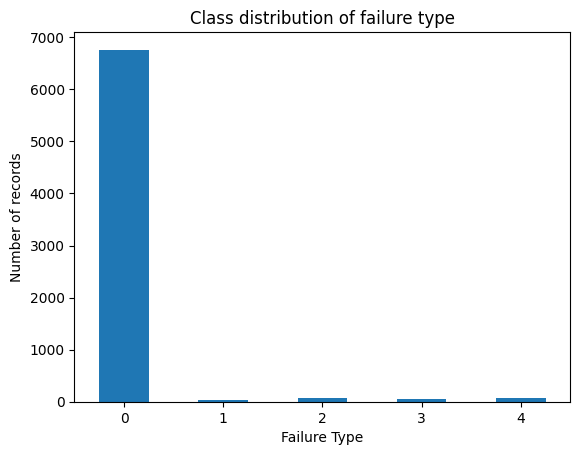


Type distribution:
      Count  Percentage
Type                   
H       706       10.10
L      4213       60.25
M      2074       29.66


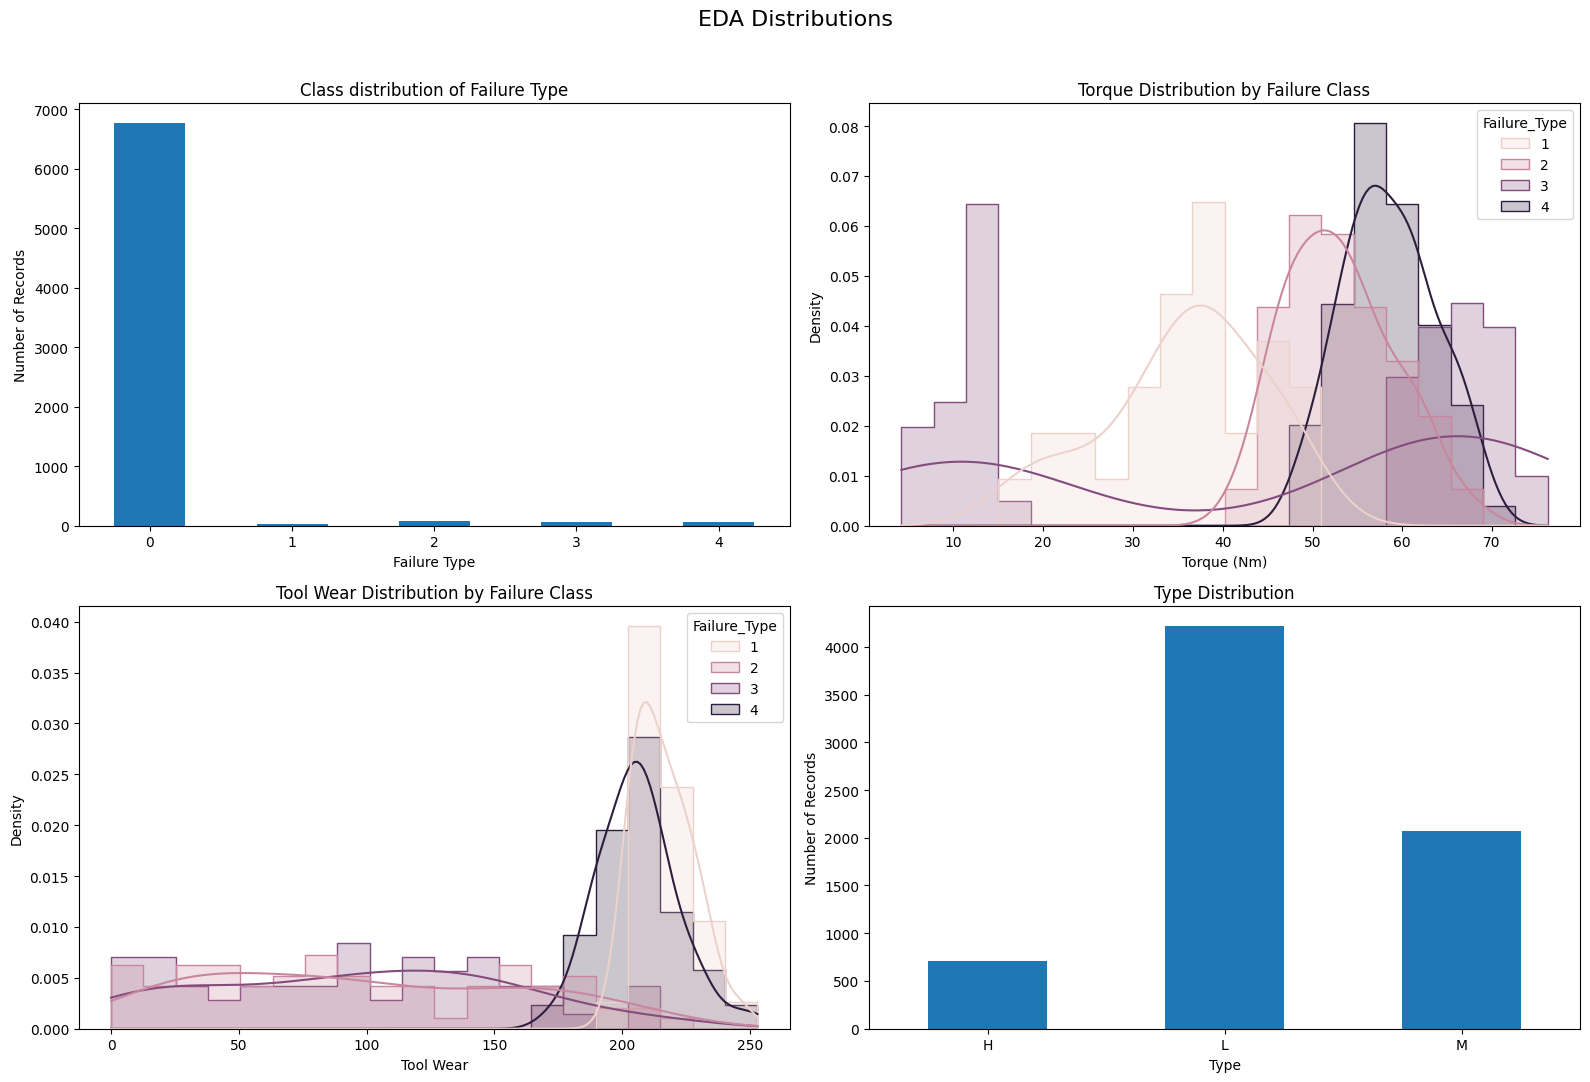


Saved figure as: eda_distributions.png


In [ ]:
# TODO: Class distribution (print + bar chart)
class_counts = train['Failure_Type'].value_counts().sort_index()

class_percentage = (train['Failure_Type']
                    .value_counts(normalize=True)
                    .sort_index()
                    .mul(100)
                    .round(2))

distribution = pd.DataFrame({
    'Count': class_counts,
    'Percentage': class_percentage
})

print('Failure Type class distribution:')
print(distribution)

#Visualization
train['Failure_Type'].value_counts().sort_index().plot(
    kind="bar",
    xlabel="Failure Type",
    ylabel="Number of records",
    title="Class distribution of failure type"
)

plt.xticks(rotation=0)
plt.show()

# TODO: Torque distribution by failure type (histogram, failures only)
failures = train[train['Failure_Type'] !=0].copy()

type_counts = train["Type"].value_counts().sort_index()

type_percentage = (
    train["Type"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

type_distribution = pd.DataFrame(
   {
       "Count": type_counts,
       "Percentage": type_percentage
   }
)

print("\nType distribution:")
print(type_distribution)

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(16, 11)
)

# Failure_Type class distribution
class_counts.plot(
    kind="bar",
    ax=axes[0,0]
)

axes[0, 0].set_title("Class distribution of Failure Type")
axes[0, 0].set_xlabel("Failure Type")
axes[0, 0].set_ylabel("Number of Records")
axes[0, 0].tick_params(axis="x", rotation=0)

# Torque distribution for failure only
sns.histplot(
    data=failures,
    x="Torque",
    hue="Failure_Type",
    bins=20,
    kde=True,
    element="step",
    stat="density",
    common_norm=False,
    ax=axes[0, 1]
    )

axes[0, 1].set_title("Torque Distribution by Failure Class")
axes[0, 1].set_xlabel("Torque (Nm)")
axes[0, 1].set_ylabel("Density")

# Tool wear distribution for failure only
sns.histplot(
    data=failures,
    x="Tool wear",
    hue="Failure_Type",
    bins=20,
    kde=True,
    element="step",
    stat="density",
    common_norm=False,
    ax=axes[1, 0]
)

axes[1, 0].set_title("Tool Wear Distribution by Failure Class")
axes[1, 0].set_xlabel("Tool Wear")
axes[1, 0].set_ylabel("Density")

# type distribution
type_counts.plot(
    kind="bar",
    ax=axes[1, 1]
)

axes[1, 1].set_title("Type Distribution")
axes[1, 1].set_xlabel("Type")
axes[1, 1].set_ylabel("Number of Records")
axes[1, 1].tick_params(axis="x", rotation=0)

fig.suptitle(
    "EDA Distributions",
    fontsize=16
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig(
    "/content/drive/MyDrive/Upgrad/MLOps_Capstone_project/MLOps Assignment - Files/eda_distributions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
print("\nSaved figure as: eda_distributions.png")

### **1.4** <font color=red></font> Feature Engineering

Compute the following derived features for all three datasets:

**Mechanical power** (Watts):
$$P = \text{Torque} \times \frac{\text{Rotational speed} \times 2\pi}{60}$$

**Temperature differential**:
$$\Delta T = \text{Process temperature} - \text{Air temperature}$$

Print the mean of each new feature grouped by `Failure_Type`.


In [ ]:
def engineer_features(df):
    df = df.copy()
    # TODO: Compute Power_W
    # Mechanical power:
    df["Power_W"] = (
        df["Torque"] * (df["Rotational speed"] * 2 * np.pi)/ 60
    )
    # TODO: Compute Temp_diff
    # Temperature differential

    df["Temp_diff"] = (
        df["Process temperature"] - df["Air temperature"]
    )
    return df

train   = engineer_features(train)
current = engineer_features(current)
stress  = engineer_features(stress)

# TODO: Print grouped mean
datasets = {
    "Train": train,
    "Current": current,
    "Stress": stress
}

for dataset_name, df in datasets.items():
  grouped_means = (
      df.groupby("Failure_Type")[["Power_W", "Temp_diff"]]
      .mean()
      .round(2)
  )

print(f"\n{dataset_name} dataset:")
print(grouped_means)


Stress dataset:
              Power_W  Temp_diff
Failure_Type                    
0             6762.74       9.97
1             6213.17       9.67
2             8042.59       8.21
3             7570.23      10.13
4             8176.59       9.99


## **2. Experiment Tracking & Model Selection** <font color=red></font>

### **2.1** <font color=red></font> Setup: features, split, SMOTE

Use the features below. Apply a stratified 80/20 train-val split (random_state=42).
Apply SMOTE to the training split only. Print the post-SMOTE class distribution.

```
FEATURES = ['Type_enc', 'Air temperature', 'Process temperature',
            'Rotational speed', 'Torque', 'Tool wear', 'Power_W', 'Temp_diff']
```

> In a markdown cell below the code, explain in 2–3 sentences why SMOTE is applied
> only to the training split and not the validation set.


In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

import joblib

# TODO: Encode Type column
le = LabelEncoder()
train['Type_enc']   = le.fit_transform(train['Type'])
current['Type_enc'] = le.transform(current['Type'])
stress['Type_enc']  = le.transform(stress['Type'])

joblib.dump(le, "label_encoder.pkl")

print("Saved label encoder as label_encoder.pkl")
print("Class mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

FEATURES = ['Type_enc', 'Air temperature', 'Process temperature',
            'Rotational speed', 'Torque', 'Tool wear', 'Power_W', 'Temp_diff']

# TODO: Define X and y
X = train[FEATURES]
y = train["Failure_Type"]

# TODO: Train-val split
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Class distribution before SMOTE:")
print(y_train.value_counts().sort_index())

# TODO: Apply SMOTE (k_neighbors=3, random_state=42)
smote = SMOTE(
    k_neighbors=3,
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("\nPost SMOTE class distribution:")
print(y_train_smote.value_counts().sort_index())
# TODO: Print post-SMOTE class distribution


Saved label encoder as label_encoder.pkl
Class mapping: {'H': np.int64(0), 'L': np.int64(1), 'M': np.int64(2)}
Class distribution before SMOTE:
Failure_Type
0    5409
1      24
2      61
3      45
4      55
Name: count, dtype: int64

Post SMOTE class distribution:
Failure_Type
0    5409
1    5409
2    5409
3    5409
4    5409
Name: count, dtype: int64


*Your explanation here: why is SMOTE applied only on the training split?*

SMOTE has been applied only to the training data, not on the validation data. As SMOTE creates synthetic data to mitigate the class imbalance problem. Adding augmented data to the validation data using SMOTE would create unrealistic validation performance, because the validation data should be unseen data.

### **2.2** <font color=red></font> Train and log 4 models with MLflow

Train and evaluate:
- Logistic Regression
- Random Forest (n_estimators=100)
- XGBoost (n_estimators=100)
- LightGBM (n_estimators=100)

MLflow experiment name: `PredMaint_ModelSelection`

For each run log: `model` (param), `macro_f1`, `weighted_f1`, `accuracy` (metrics),
and per-class F1 for all 5 classes. Print a comparison table. Pick the best model by macro F1.


In [ ]:
pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 85.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 94.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 71.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 112.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.3/121.3 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1

In [ ]:
import mlflow
import mlflow.sklearn
from sklearn.metrics import f1_score, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

mlflow.set_tracking_uri('sqlite:///mlflow.db')
mlflow.set_experiment('PredMaint_ModelSelection')

CLASS_LIST = [0, 1, 2, 3, 4]
results = {}

models_to_run = {
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(max_iter=2000, random_state=42,
                                  class_weight='balanced'))
    ]),
    'RandomForest':       RandomForestClassifier(n_estimators=100, random_state=42,
                                                  class_weight='balanced'),
    'XGBoost':            XGBClassifier(n_estimators=100, random_state=42,
                                         eval_metric='mlogloss', verbosity=0),
    'LightGBM':           LGBMClassifier(n_estimators=100, random_state=42,
                                          class_weight='balanced', verbose=-1),
}

# TODO: For each model:
#   - Start an MLflow run
#   - Fit on X_res, y_res
#   - Predict on X_val
#   - Compute and log macro_f1, weighted_f1, accuracy, per-class F1
#   - Log the model artefact (use input_example=X_val.iloc[:5])
for model_name, model in models_to_run.items():

  with mlflow.start_run(run_name=model_name):

    # Log model name as a parameter
    mlflow.log_param("model", model_name)
    mlflow.log_param("n_estimators", model.get_params().get("n_estimators", "NA"))
    mlflow.log_param("random_state", 42)

    # Train on the SMOTE-resampled training split
    model.fit(X_train_smote, y_train_smote)

    # Predict on the original validation split
    y_pred = model.predict(X_val)

    # Metrics calculations
    macro_f1 = f1_score(
        y_val,
        y_pred,
        average="macro",
        labels=CLASS_LIST,
        zero_division=0
    )

    weighted_f1 = f1_score(
        y_val,
        y_pred,
        average="weighted",
        labels=CLASS_LIST,
        zero_division=0
    )

    accuracy = accuracy_score(y_val, y_pred)

    # F1 score for each individual class
    class_f1_scores = f1_score(
        y_val,
        y_pred,
        average=None,
        labels=CLASS_LIST,
        zero_division=0

    )

    # Metrics to log in MLflow
    metrics = {
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "accuracy": accuracy
    }

    for class_label, class_f1 in zip(
        CLASS_LIST,
        class_f1_scores
    ):
      metrics[f"f1_class_{class_label}"] = class_f1

    mlflow.log_metrics(metrics)

    # Log the fitted model
    if model_name == "XGBoost":
        mlflow.xgboost.log_model(
            xgb_model=model,
            name="model",
            input_example=X_val.iloc[:5],
            model_format="json"
        )

    elif model_name == "LightGBM":
      mlflow.lightgbm.log_model(
          lgb_model=model,
          name="model",
          input_example=X_val.iloc[:5]
      )

    else:
        mlflow.sklearn.log_model(
        sk_model=model,
        name="model",
        input_example=X_val.iloc[:5]
    )

    # Strore results for comparison
    results[model_name] = {
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "accuracy": accuracy,
        **{
            f"f1_class_{class_label}": class_f1
            for class_label, class_f1 in zip(
                CLASS_LIST,
                class_f1_scores
            )
        }
    }

    print(f"Completed: {model_name}")

# TODO: Print comparison table
comparison_df = (
    pd.DataFrame.from_dict(results, orient="index")
    .reset_index()
    .rename(columns={"index": "model"})
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)

# round metric values for disply
metric_columns = comparison_df.columns.drop("model")
comparison_df[metric_columns] = comparison_df[metric_columns].round(4)

print("\nModel comparison:")
print(comparison_df.to_string(index=False))

# TODO: Identify best model by macro F1
best_model_name = comparison_df.loc[0, "model"]
best_macro_f1 = comparison_df.loc[0, "macro_f1"]

print("\nBest model based on macro F1:")
print(f"{best_model_name} - Macro F1: {best_macro_f1:.4f}")

best_model = models_to_run[best_model_name]

# save the best fitted model
joblib.dump(best_model, "best_model.pkl")

print("\nBest model saved sucessfully as best_model.pkl")


2026/07/28 10:34:36 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/28 10:34:36 INFO mlflow.store.db.utils: Updating database tables
2026/07/28 10:34:43 INFO mlflow.tracking.fluent: Experiment with name 'PredMaint_ModelSelection' does not exist. Creating a new experiment.


Completed: LogisticRegression
Completed: RandomForest
Completed: XGBoost
Completed: LightGBM

Model comparison:
             model  macro_f1  weighted_f1  accuracy  f1_class_0  f1_class_1  f1_class_2  f1_class_3  f1_class_4
      RandomForest    0.7355       0.9855    0.9850      0.9926      0.0000      0.9286      0.9565      0.8000
          LightGBM    0.7296       0.9851    0.9843      0.9922      0.0000      0.9655      0.8333      0.8571
           XGBoost    0.7274       0.9842    0.9828      0.9915      0.0000      0.9655      0.8800      0.8000
LogisticRegression    0.5312       0.9328    0.9042      0.9483      0.1449      0.4545      0.4583      0.6500

Best model based on macro F1:
RandomForest - Macro F1: 0.7355

Best model saved sucessfully as best_model.pkl


### **2.3** <font color=red></font> Optuna tuning + MLflow Model Registry

Run an Optuna study (30 trials, `TPESampler(seed=42)`) tuning XGBoost hyperparameters.
Optimise for `macro_f1` on `X_val`.

MLflow experiment: `PredMaint_Optuna`

Register the best model as `PredMaint_XGBoost` and promote it to the `production` alias.
Print the improvement in macro F1 over the baseline XGBoost.


In [ ]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 8.3 MB/s eta 0:00:00


In [ ]:
import optuna
import joblib
from mlflow import MlflowClient

optuna.logging.set_verbosity(optuna.logging.WARNING)
mlflow.set_experiment('PredMaint_Optuna')

CLASS_LIST = [0, 1, 2, 3, 4]
REGISTERED_MODEL_NAME = "PredMaint_XGBoost"

# ---------------------------------------------------------
# Get baseline XGBoost macro F1 from the previous step
# ---------------------------------------------------------
if "XGBoost" not in results:
    raise ValueError(
        "Baseline XGBoost results were not found. "
        "Run the model-selection cell first."
    )

baseline_macro_f1 = results["XGBoost"]["macro_f1"]

print(f"Baseline XGBoost macro F1: {baseline_macro_f1:.4f}")

def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 500),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'min_child_weight':  trial.suggest_float('min_child_weight', 1.0, 10.0),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma':             trial.suggest_float('gamma', 0.0, 2.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 5.0, log=True),
        'random_state': 42, 'eval_metric': 'mlogloss', 'verbosity': 0,
    }
    # TODO: Train XGBoost model, return macro_f1 on X_val
    model = XGBClassifier(**params)

    # Train only on the SMOTE-resampled training split
    model.fit(X_train_smote, y_train_smote)

    # Evaluate on the untouched validation set
    y_pred = model.predict(X_val)

    macro_f1 = f1_score(
        y_val,
        y_pred,
        labels=CLASS_LIST,
        average="macro",
        zero_division=0
    )

    return macro_f1

study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=42))
# TODO: Run study.optimize

# TODO: Train final best model
# TODO: Log to MLflow, register as 'PredMaint_XGBoost', promote to production alias
# TODO: Save with joblib.dump

study.optimize(
    objective,
    n_trials=30,
    show_progress_bar=True
)

print("\nBest Optuna trial:")
print(f"Trial number : {study.best_trial.number}")
print(f"Macro F1     : {study.best_value:.4f}")

print("\nBest hyperparameters:")
for parameter, value in study.best_params.items():
    print(f"{parameter}: {value}")

# ---------------------------------------------------------
# Train final tuned XGBoost model
# ---------------------------------------------------------

# Train final best model
best_params = {
    **study.best_params,
    "random_state": 42,
    "eval_metric": "mlogloss",
    "verbosity": 0,
    "n_jobs": -1
}

tuned_xgb = XGBClassifier(**best_params)

tuned_xgb.fit(
    X_train_smote,
    y_train_smote
)

tuned_pred = tuned_xgb.predict(X_val)

# ---------------------------------------------------------
# Evaluate tuned model
# ---------------------------------------------------------
tuned_macro_f1 = f1_score(
    y_val,
    tuned_pred,
    labels=CLASS_LIST,
    average="macro",
    zero_division=0
)

tuned_weighted_f1 = f1_score(
    y_val,
    tuned_pred,
    labels=CLASS_LIST,
    average="weighted",
    zero_division=0
)

tuned_accuracy = accuracy_score(
    y_val,
    tuned_pred
)

tuned_class_f1 = f1_score(
    y_val,
    tuned_pred,
    labels=CLASS_LIST,
    average=None,
    zero_division=0
)

# ---------------------------------------------------------
# Compare tuned XGBoost with baseline XGBoost
# ---------------------------------------------------------
absolute_improvement = (
    tuned_macro_f1 - baseline_macro_f1
)

relative_improvement_percentage = (
    absolute_improvement / baseline_macro_f1 * 100
    if baseline_macro_f1 != 0
    else float("nan")
)

print("\nXGBoost macro F1 comparison:")
print(f"Baseline XGBoost : {baseline_macro_f1:.4f}")
print(f"Tuned XGBoost    : {tuned_macro_f1:.4f}")
print(f"Absolute change  : {absolute_improvement:+.4f}")
print(
    f"Relative change  : "
    f"{relative_improvement_percentage:+.2f}%"
)

# ---------------------------------------------------------
# Log tuned model to MLflow and register it
# ---------------------------------------------------------
# TODO: Log to MLflow, register as 'PredMaint_XGBoost',
# promote to production alias
with mlflow.start_run(
    run_name="Optuna_Best_XGBoost"
) as run:

    mlflow.log_param("model", "XGBoost")
    mlflow.log_param("optimization_method", "Optuna")
    mlflow.log_param("sampler", "TPESampler")
    mlflow.log_param("sampler_seed", 42)
    mlflow.log_param("n_trails", 30)
    mlflow.log_param(
        "best_trail_number", study.best_trial.number
    )

    mlflow.log_params(best_params)

    metrics = {
        "macro_f1": tuned_macro_f1,
        "weighted_f1": tuned_weighted_f1,
        "accuracy": tuned_accuracy,
        "baseline_macro_f1": baseline_macro_f1,
        "macro_f1_improvement": absolute_improvement,
        "relative_improvement_percent": relative_improvement_percentage
        }

    for class_label, class_score in zip(
        CLASS_LIST,
        tuned_class_f1
    ):

      metrics[f"f1_class_{class_label}"] = float(class_score)

    mlflow.log_metrics(metrics)

    model_info = mlflow.xgboost.log_model(
        xgb_model=tuned_xgb,
        name="model",
        input_example=X_val.iloc[:5],
        registered_model_name=REGISTERED_MODEL_NAME,
        model_format="json"
    )

    best_run_id = run.info.run_id

print("\nTuned model logged and registered.")
print(f"MLflow run ID: {best_run_id}")

# ---------------------------------------------------------
# Assign production alias
# ---------------------------------------------------------
client= MlflowClient()

model_versions = client.search_model_versions(
    f"name='{REGISTERED_MODEL_NAME}'"
)

matching_versions = [
    model_version
    for model_version in model_versions
    if model_version.run_id == best_run_id
]

if not matching_versions:
  raise RuntimeError(
        "Could not find the registered model version "
        "created by the current MLflow run."
  )

registered_version = max(
    matching_versions,
    key=lambda model_version: int(
        model_version.version
    )
)

best_version = registered_version.version

client.set_registered_model_alias(
    name=REGISTERED_MODEL_NAME,
    alias="production",
    version=best_version
)

print("\nModel registration details:")
print(f"Registered model : {REGISTERED_MODEL_NAME}")
print(f"Model version    : {best_version}")
print("Alias            : production")

# ---------------------------------------------------------
# Save tuned production candidate locally
# ---------------------------------------------------------
joblib.dump(
    tuned_xgb,
    "best_model.pkl"
)

print("\nTuned XGBoost saved as: best_model.pkl")

Baseline XGBoost macro F1: 0.7274


  0%|          | 0/30 [00:00<?, ?it/s]


Best Optuna trial:
Trial number : 1
Macro F1     : 0.7678

Best hyperparameters:
n_estimators: 383
max_depth: 3
learning_rate: 0.2708160864249968
min_child_weight: 8.491983767203795
subsample: 0.6849356442713105
colsample_bytree: 0.6727299868828402
gamma: 0.36680901970686763
reg_alpha: 2.716051144654844e-06
reg_lambda: 0.0003671474011048667

XGBoost macro F1 comparison:
Baseline XGBoost : 0.7274
Tuned XGBoost    : 0.7678
Absolute change  : +0.0404
Relative change  : +5.56%

Tuned model logged and registered.
MLflow run ID: 85194428c8634b18936892be9e6f9ab2

Model registration details:
Registered model : PredMaint_XGBoost
Model version    : 1
Alias            : production

Tuned XGBoost saved as: best_model.pkl


Successfully registered model 'PredMaint_XGBoost'.
Created version '1' of model 'PredMaint_XGBoost'.


## **3. Drift Detection & Monitoring** <font color=red></font>

> Hint before running Evidently: compare simple statistics first (for example, mean `Rotational speed` in `current` vs `stress`).
> Reminder: passing Pandera only means values are valid; it does **not** mean the batch is in-distribution.
> Section objective: identify why the deployed model is stale on stress conditions.

### **3.1** <font color=red></font> Evidently — current batch

Reference: `train[FEAT_COLS]` | Current: `current[FEAT_COLS]`

```
FEAT_COLS = ['Air temperature', 'Process temperature',
             'Rotational speed', 'Torque', 'Tool wear']
```

Run `DataDriftPreset`. Save HTML to `drift_current.html`.
Report: drift detected? How many features drifted?


In [ ]:
pip install evidently

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 78.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 270.3/270.3 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.8/581.8 kB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.2/72.2 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 44.6 MB/s eta 0:00:00


In [ ]:
from evidently.legacy.report import Report
from evidently.legacy.metric_preset import DataDriftPreset

FEAT_COLS = ['Air temperature', 'Process temperature',
             'Rotational speed', 'Torque', 'Tool wear']

# TODO: Run Evidently on current batch, save drift_current.html, print summary
# ---------------------------------------------------------
# 1. Compare simple statistics first
# ---------------------------------------------------------
print("Mean feature values:")
print("\nTraining data:")
print(train[FEAT_COLS].mean().round(2))

print("\nCurrent batch:")
print(current[FEAT_COLS].mean().round(2))

print("\nDifference: current - train")
print(
    (
        current[FEAT_COLS].mean() - train[FEAT_COLS].mean()
    ).round(2)

)

# ---------------------------------------------------------
# 2. Run Evidently DataDriftPreset
# ---------------------------------------------------------
drift_report_current = Report(
    metrics=[
        DataDriftPreset()
    ]
)

drift_report_current.run(
    reference_data=train[FEAT_COLS],
    current_data=current[FEAT_COLS]
)

# ---------------------------------------------------------
# 3. Save the HTML report
# ---------------------------------------------------------
drift_report_current.save_html(
    "drift_current.html"
)

print("\nSaved report as: drift_current.html")

# ---------------------------------------------------------
# 4. Extract and print drift summary
# ---------------------------------------------------------
report_dict = drift_report_current.as_dict()

# The DataDriftPreset summary is generally stored in the
# first metric result.
drift_result = report_dict["metrics"][0]["result"]

dataset_drift = drift_result["dataset_drift"]
number_of_drifted_features = drift_result["number_of_drifted_columns"]
share_of_drifted_features = drift_result["share_of_drifted_columns"]

print("\nDrift summary:")
print(f"Drift detected: {dataset_drift}")
print(
    f"Features drifted: "
    f"{number_of_drifted_features}/{len(FEAT_COLS)}"
)
print(
    f"Share of drifted features: "
    f"{share_of_drifted_features:.2%}"
)

Mean feature values:

Training data:
Air temperature         300.01
Process temperature     310.00
Rotational speed       1539.02
Torque                   40.00
Tool wear               107.68
dtype: float64

Current batch:
Air temperature         299.92
Process temperature     310.00
Rotational speed       1530.17
Torque                   40.22
Tool wear               108.20
dtype: float64

Difference: current - train
Air temperature       -0.09
Process temperature   -0.00
Rotational speed      -8.85
Torque                 0.22
Tool wear              0.52
dtype: float64

Saved report as: drift_current.html

Drift summary:
Drift detected: False
Features drifted: 0/5
Share of drifted features: 0.00%


### **3.2** <font color=red></font> Evidently - stress batch

Repeat for `stress.csv`. Use `ColumnDriftMetric` for individual feature scores.
Save as `drift_stress.html`.
Print a table: feature | drift detected | Wasserstein score | ref mean | current mean | delta.

Focus question: this section is about diagnosing *staleness risk* (what shifted and why), not "making stress predictions look good."

In [ ]:
from evidently.legacy.metrics.data_drift.dataset_drift_metric import DatasetDriftMetric
from evidently.legacy.metrics.data_drift.column_drift_metric import ColumnDriftMetric

# TODO: Run Evidently on stress batch with per-column metrics
# TODO: Save drift_stress.html
# TODO: Print per-column drift table

# ---------------------------------------------------------
# 1. Compare simple statistics first
# ---------------------------------------------------------
simple_comparison = pd.DataFrame({
    "ref_mean": train[FEAT_COLS].mean(),
    "stress_mean": stress[FEAT_COLS].mean()
})

simple_comparison["delta"] = (
    simple_comparison["stress_mean"]
    - simple_comparison["ref_mean"]
)

print("Simple mean comparison: training vs stress")
print(simple_comparison.round(2))


# ---------------------------------------------------------
# 2. Build Evidently report
# ---------------------------------------------------------
# Wasserstein is explicitly selected so every feature has
# a comparable Wasserstein drift score.
stress_drift_report = Report(
    metrics=[
        DatasetDriftMetric(
            columns=FEAT_COLS,
            stattest="wasserstein"
        ),
        *[
            ColumnDriftMetric(
                column_name=feature,
                stattest="wasserstein"
            )
            for feature in FEAT_COLS
        ]
    ]
)


# ---------------------------------------------------------
# 3. Run report
# ---------------------------------------------------------
stress_drift_report.run(
    reference_data=train[FEAT_COLS],
    current_data=stress[FEAT_COLS]
)


# ---------------------------------------------------------
# 4. Save HTML
# ---------------------------------------------------------
stress_drift_report.save_html("drift_stress.html")

print("\nSaved report as: drift_stress.html")


# ---------------------------------------------------------
# 5. Extract report results
# ---------------------------------------------------------
report_dict = stress_drift_report.as_dict()

# First metric is DatasetDriftMetric
dataset_result = report_dict["metrics"][0]["result"]

dataset_drift = dataset_result["dataset_drift"]
number_drifted = dataset_result["number_of_drifted_columns"]
share_drifted = dataset_result["share_of_drifted_columns"]


# Remaining metrics are one ColumnDriftMetric per feature
drift_rows = []

for feature, metric_output in zip(
    FEAT_COLS,
    report_dict["metrics"][1:]
):
    result = metric_output["result"]

    ref_mean = train[feature].mean()
    stress_mean = stress[feature].mean()

    drift_rows.append({
        "feature": feature,
        "drift detected": result["drift_detected"],
        "Wasserstein score": result["drift_score"],
        "ref mean": ref_mean,
        "current mean": stress_mean,
        "delta": stress_mean - ref_mean
    })


drift_stress_table = pd.DataFrame(drift_rows)

# Round only numerical display columns
numeric_cols = [
    "Wasserstein score",
    "ref mean",
    "current mean",
    "delta"
]

drift_stress_table[numeric_cols] = (
    drift_stress_table[numeric_cols].round(4)
)


# ---------------------------------------------------------
# 6. Print dataset-level and feature-level results
# ---------------------------------------------------------
print("\nStress drift summary:")
print(f"Drift detected: {dataset_drift}")
print(f"Features drifted: {number_drifted}/{len(FEAT_COLS)}")
print(f"Share of drifted features: {share_drifted:.2%}")

print("\nPer-feature drift results:")
print(drift_stress_table.to_string(index=False))


Simple mean comparison: training vs stress
                     ref_mean  stress_mean  delta
Air temperature        300.01       300.05   0.04
Process temperature    310.00       310.01   0.00
Rotational speed      1539.02      1497.07 -41.94
Torque                  40.00        44.72   4.73
Tool wear              107.68       148.87  41.19

Saved report as: drift_stress.html

Stress drift summary:
Drift detected: True
Features drifted: 3/5
Share of drifted features: 60.00%

Per-feature drift results:
            feature  drift detected  Wasserstein score  ref mean  current mean    delta
    Air temperature           False             0.0344  300.0116      300.0538   0.0422
Process temperature           False             0.0377  310.0049      310.0086   0.0037
   Rotational speed            True             0.2354 1539.0176     1497.0747 -41.9429
             Torque            True             0.4739   39.9958       44.7241   4.7283
          Tool wear            True             0.645

### **3.3** <font color=red></font> Retraining decision

Answer the following in a markdown cell:
1. Which features drifted in the stress batch?
2. Cross-referencing with your SHAP results (Section 4) ? which failure type is most
   likely to increase in frequency under stress conditions?
3. Should the model be retrained? Justify with evidence from Sections 3.1, 3.2, and 4.

Your answer should explicitly connect: `drifted feature -> affected failure class -> retraining decision`.

**Your answer here:**

1. Features that drifted: Rotational speed, Torque and Tool wear.
2. Most likely failure type to increase: Primarily OSF, followed by TWF; possible secondary effects on PWF and HDF.
3. Retraining recommendation: Retrain when stress operation is expected to continue, because 60% of monitored features drifted and the shifted variables are major SHAP drivers of failure classification.


## **4. Explainability & Insights** <font color=red></font>

> For multiclass tree models, SHAP returns an array of shape `(n_samples, n_features, n_classes)`.
>
> **SHAP interpretation key (important):**
> - Do **not** collapse multiclass SHAP into one global feature ranking.
> - Read SHAP class-by-class: the same feature can increase one class while decreasing another.
> - Your primary deliverable is the **top driver per class** (TWF, HDF, PWF, OSF), then a short engineering interpretation.

### **4.1** <font color=red></font> SHAP analysis per failure class

Load `best_model.pkl`. Use `shap.TreeExplainer` on `train[FEATURES]`.
Plot mean |SHAP| bar charts for TWF, HDF, PWF, OSF (4 subplots). Save as `shap_per_class.png`.
Print the top driver for each failure class.

Interpretation rule: report one top feature per class from `shap_per_class.png`; avoid a single cross-class "global winner."

Model classes: [0 1 2 3 4]
SHAP input shape: (6993, 8)
Final SHAP array shape: (6993, 8, 5)


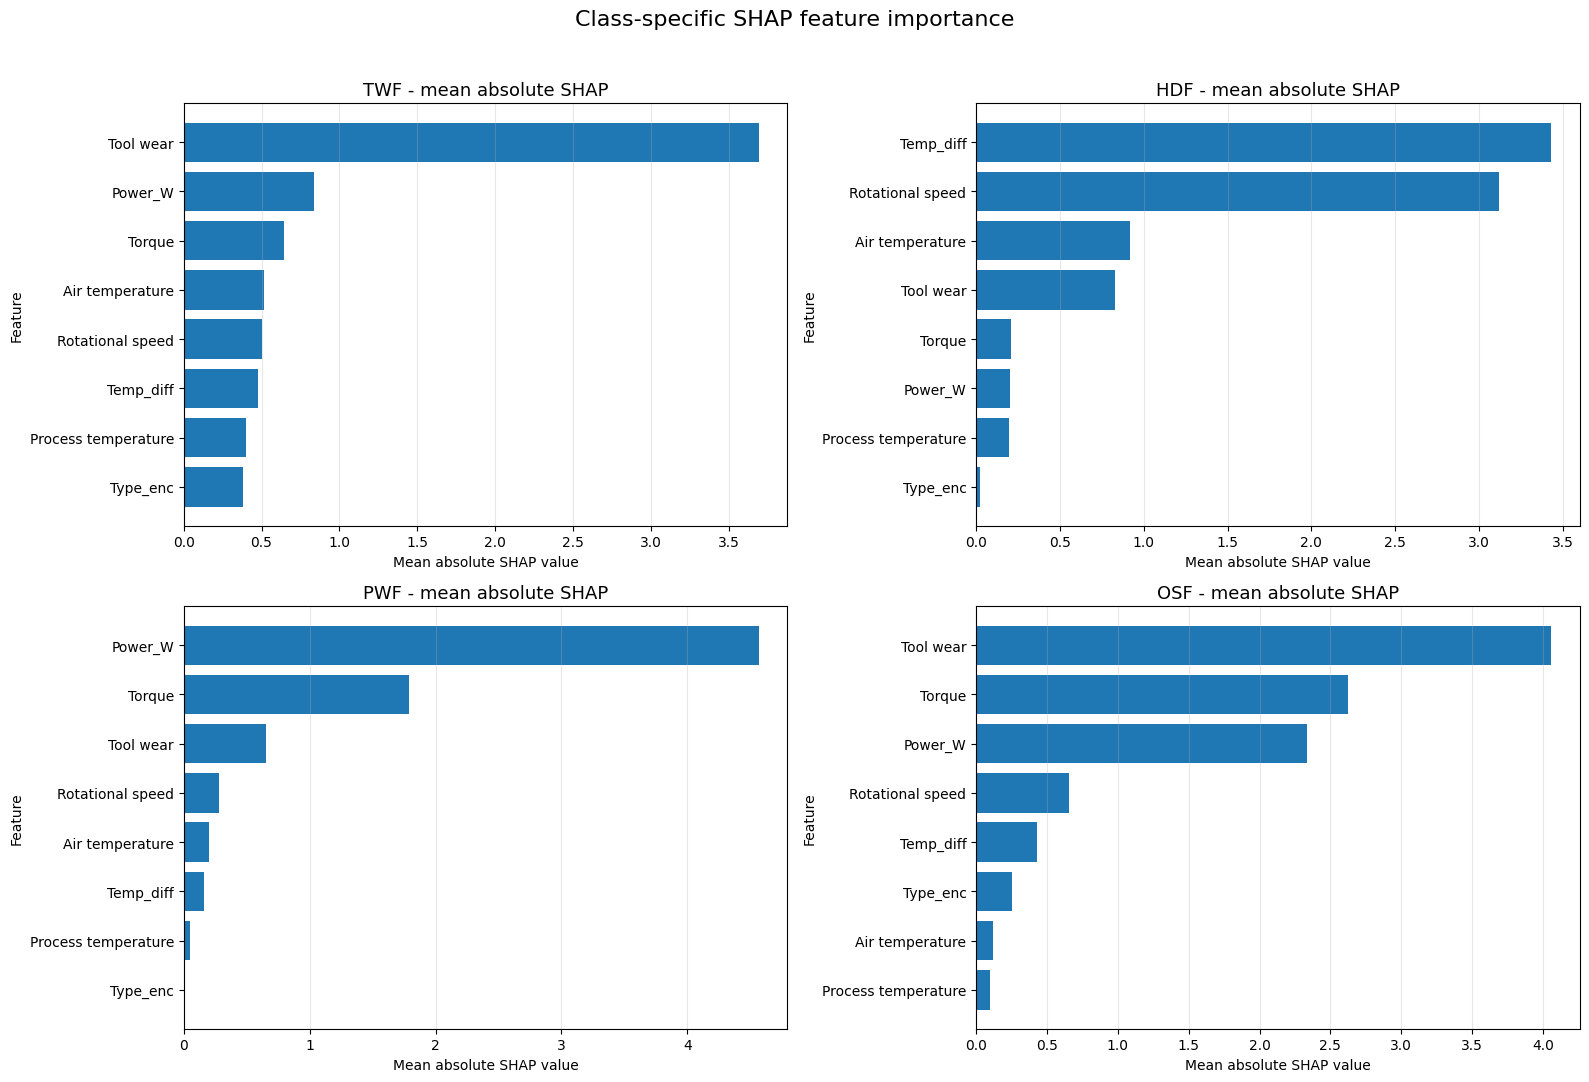


Saved plot as: shap_per_class.png

Top SHAP driver by failure class:
TWF: {'TWF': 'Tool wear', 'HDF': 'Temp_diff', 'PWF': 'Power_W', 'OSF': 'Tool wear'} (mean absolute SHAP = 3.6926)
HDF: {'TWF': 'Tool wear', 'HDF': 'Temp_diff', 'PWF': 'Power_W', 'OSF': 'Tool wear'} (mean absolute SHAP = 3.4306)
PWF: {'TWF': 'Tool wear', 'HDF': 'Temp_diff', 'PWF': 'Power_W', 'OSF': 'Tool wear'} (mean absolute SHAP = 4.5669)
OSF: {'TWF': 'Tool wear', 'HDF': 'Temp_diff', 'PWF': 'Power_W', 'OSF': 'Tool wear'} (mean absolute SHAP = 4.0585)


In [ ]:
import shap

best_model = joblib.load('best_model.pkl')

X_shap = train[FEATURES].copy()

print("Model classes:", best_model.classes_)
print("SHAP input shape:", X_shap.shape)


# TODO: Compute SHAP values using TreeExplainer
# ---------------------------------------------------------
# 2. Compute multiclass SHAP values
# ---------------------------------------------------------
explainer = shap.TreeExplainer(best_model)
raw_shap_values = explainer.shap_values(X_shap)

if isinstance(raw_shap_values, list):
    shap_values = np.stack(raw_shap_values, axis=2)
else:
  shap_values = np.asarray(raw_shap_values)

  if (
      shap_values.ndim == 3
      and shap_values.shape[0] == len(best_model.classes_)
      and shap_values.shape[1] == len(X_shap)
  ):
    shap_values = np.transpose(shap_values, (1, 2, 0))

expected_shape = (
    len(X_shap),
    len(FEATURES),
    len(best_model.classes_)
)

if shap_values.shape != expected_shape:
  raise ValueError(
      "Unexpected SHAP shape. "
      f"Expected {expected_shape}, but received {shap_values.shape}."
  )

print("Final SHAP array shape:", shap_values.shape)

# ---------------------------------------------------------
# 3. Define failure-class labels
# ---------------------------------------------------------
# Failure_Type:
# 0 = No Failure
# 1 = TWF: Tool Wear Failure
# 2 = HDF: Heat Dissipation Failure
# 3 = PWF: Power Failure
# 4 = OSF: Overstrain Failure

failure_names = {
    1: "TWF",
    2: "HDF",
    3: "PWF",
    4: "OSF"
}

model_classes = list(best_model.classes_)

missing_classes = [
    class_id
    for class_id in failure_names
    if class_id not in model_classes
]

if missing_classes:
  raise ValueError(
      f"The model does not contain these failure classes: {missing_classes}"
  )

# ---------------------------------------------------------
# 4. Calculate mean absolute SHAP by class
# ---------------------------------------------------------
class_importance = {}
top_drivers = {}

for class_id, class_name in failure_names.items():

    # Locate the correct class axis instead of assuming
    # class ID and array position are always identical
    class_index = model_classes.index(class_id)

    mean_abs_shap = np.abs(
        shap_values[:,:, class_index]
    ).mean(axis=0)

    importance_df = pd.DataFrame({
        "feature": FEATURES,
        "mean_abs_shap": mean_abs_shap
    }).sort_values(
        "mean_abs_shap",
        ascending=False
    ).reset_index(drop=True)

    class_importance[class_name] = importance_df
    top_drivers[class_name] = importance_df.loc[0, "feature"]


# TODO: Plot 4-subplot bar chart (one per failure class)
# TODO: Save shap_per_class.png

# ---------------------------------------------------------
# 5. Plot four class-specific SHAP bar charts
# ---------------------------------------------------------
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(16, 11)
)

axes = axes.flatten()

for ax, (class_id, class_name) in zip(
    axes,
    failure_names.items()
):
  importance_df = class_importance[class_name]
  # Reverse order so the most important feature appears at the top
  plot_df = importance_df.sort_values(
      "mean_abs_shap",
      ascending=True
  )

  ax.barh(
      plot_df["feature"],
      plot_df["mean_abs_shap"]
  )

  ax.set_title(
      f"{class_name} - mean absolute SHAP",
      fontsize=13
  )

  ax.set_xlabel("Mean absolute SHAP value")
  ax.set_ylabel("Feature")
  ax.grid(axis="x", alpha=0.3)

fig.suptitle(
"Class-specific SHAP feature importance",
fontsize=16
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig(
"shap_per_class.png",
dpi=300,
bbox_inches="tight"
)

plt.show()

print("\nSaved plot as: shap_per_class.png")

# TODO: Print top driver per class
print("\nTop SHAP driver by failure class:")

for class_id, class_name in failure_names.items():
    importance_df = class_importance[class_name]

    top_feature = importance_df.loc[0, "feature"]
    top_score = importance_df.loc[0, "mean_abs_shap"]

    print(
      f"{class_name}: {top_drivers} "
      f"(mean absolute SHAP = {top_score:.4f})"
    )

### **4.2** <font color=red></font> Engineering insight

Answer in this markdown cell:

1. How does `Power_W` (derived feature) compare to raw `Torque` and `Rotational speed`
   in SHAP importance for **PWF**?
2. How does `Temp_diff` rank for **HDF** vs other failure types?
3. In 2-3 sentences, describe the physical mechanism behind each failure type based on SHAP.

Suggested structure for your actionable recommendation (used again in Section 5.1.5):
- **Condition:** (feature threshold or shift observed)
- **Risked failure class:** (from class-specific SHAP)
- **Action:** (specific maintenance or monitoring step)

**Your answer here:**

1. Power_W for PWF: Power_W stands out to be the most dominant feature for PWF. It's mean absolute SHAp value is higher than Torque and Rotational Speed. This means that the model relies strongly on the combined effotrs of Torque and Rotational Speed than on either variable alone. One specific maintenance step for power failure class is to monitor unusual mechanical power rather than observing torque and rotational speed.

2. Temp_diff for HDF: Temp_diff ranks the top feature contributing to the risk class HDF as compared to other risk classes. This indicates that temperature difference is a specific failure indicator for heat dissipation failure as compared to other machine failures.

3. Physical mechanisms:
TWF: Tool wear is the dominant driver, indicating that prolonged tool use progressively degrades the cutting surface and raises friction. As wear accumulates, the tool is more likely to exceed its safe operating condition and fail.

HDF: Temp_diff and rotational speed dominate, suggesting that heat generated during operation is not being removed effectively relative to ambient temperature. High-speed operation can increase heat generation, while an abnormal temperature differential signals inadequate cooling or heat dissipation.

PWF: Power_W is the strongest driver, followed by torque, showing that power failure is linked to abnormal mechanical power demand. Excessive or insufficient combinations of torque and rotational speed can move the machine outside its stable power operating range.

OSF: Tool wear, torque, and power are the main drivers, indicating that overstrain occurs when a worn tool operates under excessive mechanical load. The combined effect increases stress on the tool and drive system, making structural or overload-related failure more likely.


## **5. Conclusions** <font color=red></font>

### **5.1** <font color=red></font> Key findings

Write a structured conclusion (1 mark per point):

1. Which model won and why - reference macro F1 numbers.
2. Why accuracy is misleading here - operational cost implication.
3. TWF has F1 = 0.0 even after SMOTE + Optuna. Root cause and fix.
   - Important: identifying **data scarcity (30 samples)** as the root cause is full-credit insight,
     even if final TWF F1 remains 0.0.
4. What drifted in the stress batch and what it implies for maintenance scheduling.
5. One actionable recommendation for the engineering team based on SHAP.

## Conclusions

**1. Model selection:**
The top model selected is XGBoost based on macro F1 as 77% after hyperparameter tuning.

**2. Accuracy vs Macro F1:**
... Macro F1 gives equal importance to all five classes, including the rare failure categories, rather than allowing the dominant no-failure class to determine the result.Accuracy is misleading because most records belong to class 0, so a model can achieve high accuracy by predicting “no failure” while missing rare but operationally critical failures. In practice, these false negatives can lead to unplanned downtime, equipment damage, safety risks and higher emergency-maintenance costs.

**3. The TWF problem:**
The TWF F1 remains 0.0 even after SMOTE and Optuna primarily because this is a data-engineering limitation: only about 30 real TWF samples are available. SMOTE can create synthetic combinations, but it cannot add genuinely new failure patterns, operating environments or sensor behaviour; the next priority should be collecting more labelled TWF events, especially tool-wear trajectories before failure, machine type, material, operating load, maintenance history and time-series sensor readings.

**4. Drift and maintenance schedule:**
The stress batch showed drift in 3 of 5 features (60%): rotational speed decreased by about 41.94 rpm, torque increased by 4.73 Nm, and tool wear increased by 41.19 minutes. These shifts affect failure classes identified by SHAP—tool wear strongly affects TWF and OSF, torque affects OSF and PWF, and rotational speed is important for HDF—so inspections should be scheduled more frequently under stress conditions, with priority given to worn tools and high-load machines rather than following the normal maintenance interval.

**5. Actionable recommendation:**
Use this format: Condition -> Risked failure class -> Action.
Condition: Tool wear rises substantially above the normal training distribution while torque is also elevated.
Risked failure class: OSF, with additional risk of TWF.
Action: Trigger an early inspection or tool replacement, check mechanical loading and shorten the maintenance interval for machines operating under sustained high-wear and high-torque conditions.